# Preparação dos Dados e Protocolo Experimental

In [1]:
from sklearn import datasets
import pandas as pd
import matplotlib.pyplot as plt

data = datasets.load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

O dataset se trata de um problema binário de classificação. Cabendo ao modelo aprender a diagnosticar corretamente tumores mamários como malignos ou benignos.


---


As features de entrada usadas para previsão são as seguintes:

* a) radius (mean of distances from center to points on the perimeter)
*	b) texture (standard deviation of gray-scale values)
*	c) perimeter
*	d) area
*	e) smoothness (local variation in radius lengths)
*	f) compactness (perimeter^2 / area - 1.0)
*	g) concavity (severity of concave portions of the contour)
*	h) concave points (number of concave portions of the contour)
*	i) symmetry
*	j) fractal dimension ("coastline approximation" - 1)

Sendo que para cada uma delas há a média, o erro e o pior valor.


---


Com esses dados o modelo deve ser capaz de de prever a variável-alvo:
* Diagnosis (M = malignant, B = benign)







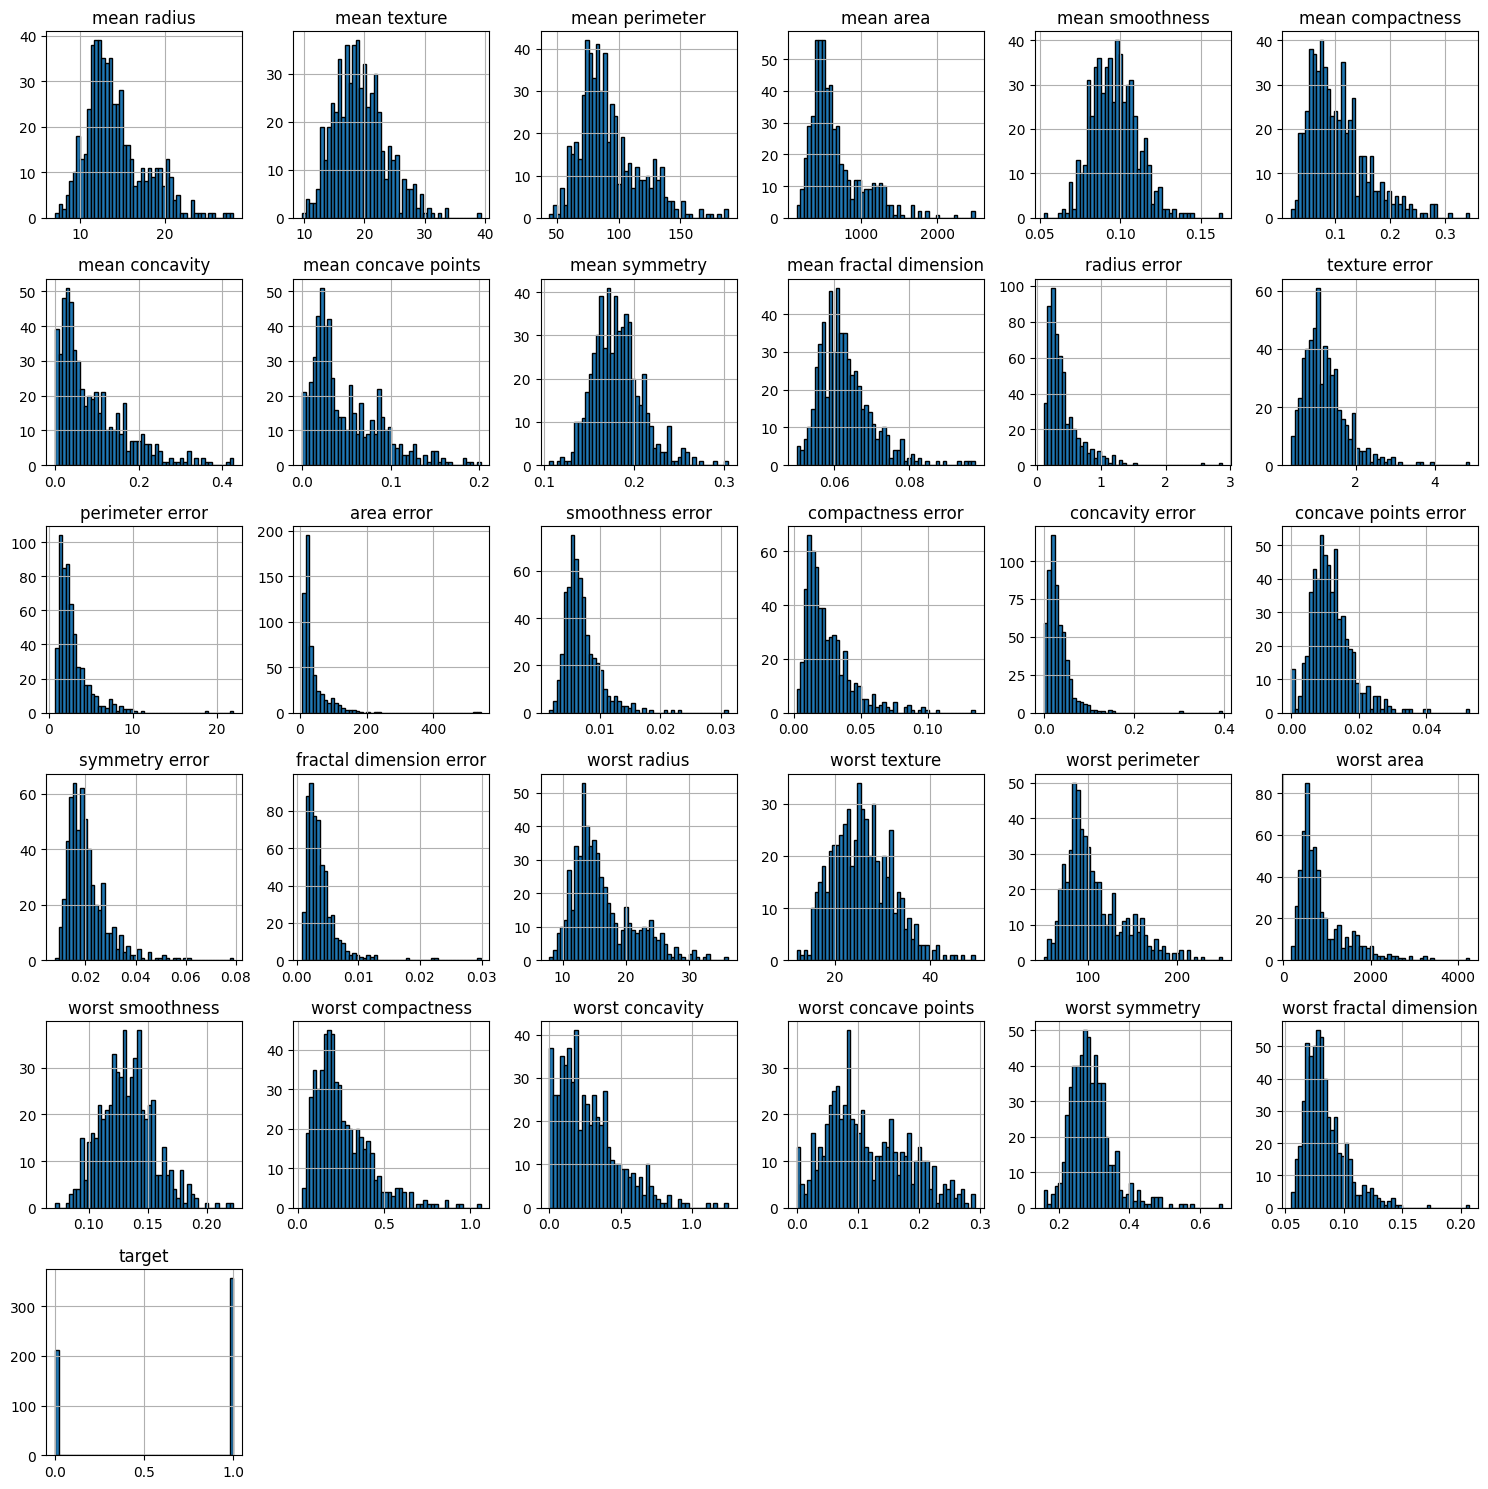

In [2]:
df.hist(figsize=(15,15), bins=50, edgecolor='black')
plt.tight_layout()
plt.show()

Analizando os dados, decidi aplicar o standard scaler na maioria das variáveis por parecerem aproximadamente normais, com exceção de concativity e concave points que juntamente com os erros terão normalização logarítmica.

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df.drop("target", axis=1)
y = df["target"]

X_dev, X_test, y_dev, y_test = train_test_split(X, y, test_size=0.2, random_state=57)
X_train, X_val, y_train, y_val = train_test_split(X_dev, y_dev, test_size=0.25, random_state=57)


logarithmic = [col for col in X.columns if "error" in col or col in ["mean concavity", "mean concave points", "worst concave points"]
]

standard = [col for col in X.columns if col not in logarithmic]

preprocessor = ColumnTransformer(
    [
        ("logarithmic", FunctionTransformer(np.log1p), logarithmic),
        ("standard", StandardScaler(), standard),
    ]
)

Assim separamos os dados em conjunto de teste, validação e treino, com o de teste somente para avaliação final de desempenho, esse conjunto tem somente esse propósito e não pode ser usado para selecionar qualquer atributo, sejam hiperparâmetros, escolher entre modelos ou pior ainda usar esse conjunto no treinamento. Tendo em vista que que isso geraria uma análise superestimada de seu desempenho.

# Modelo Linear de Referência

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model_lr = LogisticRegression(random_state=57)
pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", model_lr)])
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_val)
print(classification_report(y_val, y_pred, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.95      1.00      0.98        40
      benign       1.00      0.97      0.99        74

    accuracy                           0.98       114
   macro avg       0.98      0.99      0.98       114
weighted avg       0.98      0.98      0.98       114



Treinamos um modelo de regressão logística nos dados e usamos classification report para poder analisar as métricas obtidas.

Esse modelo é bom para se usar de base, pois é um modelo bem simples e rápido de ser treinado, tendo custo muito menor que uma rede neural. Nesse caso, ele demonstrou se ajustar muito bem aos dados, tendo um desempenho excelente. Como limitações, temos que esse modelo não é capaz de capturar relações de funções não lineares.

In [10]:
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       1.00      0.96      0.98        49
      benign       0.97      1.00      0.98        65

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



# Modelo Não Linear ou Ensemble

### Decision Tree

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

model_tree = DecisionTreeClassifier(random_state=57)
model_tree.fit(X_train, y_train)
y_pred = model_tree.predict(X_val)
print(classification_report(y_val, y_pred, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.90      0.90      0.90        40
      benign       0.95      0.95      0.95        74

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



Comparando o modelo decision tree com o logistic regression anterior podemos perceber que o atual se saiu ligeiramente pior, ambos os modelos tiveram boas métricas mostrando que puderam generalizar bem, mas o modelo mais simples obteve resultados levemente superiores. No geral as árvores tem viés baixo, mas uma variação maior.

In [11]:
y_pred = model_tree.predict(X_test)
print(classification_report(y_test, y_pred, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.96      0.96      0.96        49
      benign       0.97      0.97      0.97        65

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



### Random Forest

In [6]:
from sklearn.ensemble import RandomForestClassifier

model_rfc = RandomForestClassifier(random_state=57)
model_rfc.fit(X_train, y_train)
y_pred = model_rfc.predict(X_val)
print(classification_report(y_val, y_pred, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.97      0.95      0.96        40
      benign       0.97      0.99      0.98        74

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



O modelo de RandomForest obteve um resultado melhor que o modelo anterior, que é o esperado pelo bagging, uma união de decision trees que corrigem os erros minoritarios umas das outras pelo 'voto' da maioria, ao invés de ser uma única árvore. O que diminui a variância, também tendo alta generalização.

Porém, ainda sim, o modelo base obteve um resultado bom demais para compensar o uso de outro modelo mais complexo com maior custo computacional. Portanto, o Logistic regression seria o escolhido.

In [13]:
y_pred = model_rfc.predict(X_test)
print(classification_report(y_test, y_pred, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        49
      benign       0.98      0.98      0.98        65

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



# Ajuste Simples de Hiperparâmetros

In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

for i in range(3, 10, 2):
  model = DecisionTreeClassifier(max_depth=i, random_state=57)
  model.fit(X_train, y_train)
  y_pred = model.predict(X_val)
  print(f"Depth: {i}")
  print(classification_report(y_val, y_pred, target_names=data.target_names))

Depth: 3
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        40
      benign       0.96      0.97      0.97        74

    accuracy                           0.96       114
   macro avg       0.95      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Depth: 5
              precision    recall  f1-score   support

   malignant       0.95      0.90      0.92        40
      benign       0.95      0.97      0.96        74

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114

Depth: 7
              precision    recall  f1-score   support

   malignant       0.90      0.90      0.90        40
      benign       0.95      0.95      0.95        74

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93    

O modelo escolhido foi decision tree por ter sido o que obteve os piores resultados, com base em um grid search básico variando max_depth do modelo de 3 até 9 com passo de 2, testando os valores (3, 5, 7 e 9). Esse hiperparâmetro afeta a complexidade da árvore por restringir a quantidade de nós, obrigando o modelo a focar só nas características principais com baixa profundidade ou possibilitando criar divisões extremamente específicas com alta profundidade.

Concluimos que o modelo com profundidade 3 foi o que se saiu melhor no conjunto de validação, e foi melhor que o modelo treinado no item anterior, tendo somente métricas iguais ou superiores.

In [18]:
model = DecisionTreeClassifier(max_depth=3, random_state=57)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.96      0.94      0.95        49
      benign       0.95      0.97      0.96        65

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.96       114
weighted avg       0.96      0.96      0.96       114



Avaliando no conjunto de teste o modelo prova novamente sua capacidade de generalização com ótimos resultados similares ao conjunto de validação.

 # Aprendizado Não Supervisionado: PCA ou k-means

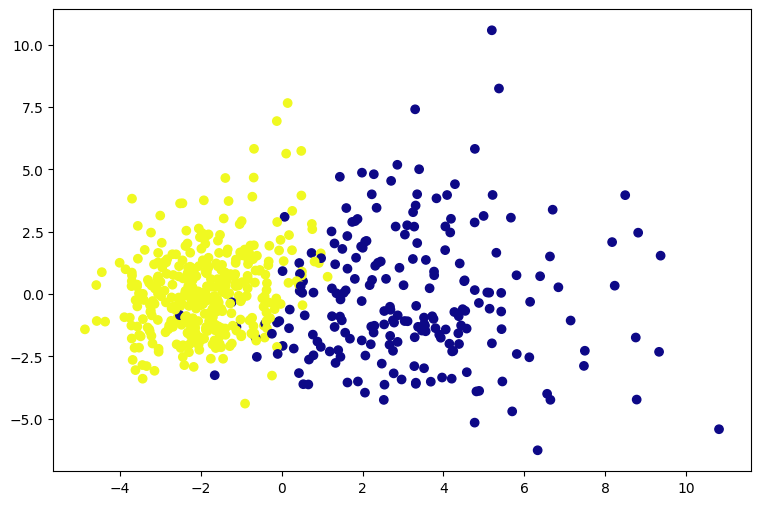

In [9]:
from sklearn.decomposition import PCA

X_scaled = preprocessor.fit_transform(X)
pca = PCA(n_components=2, random_state=57)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(9, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="plasma")
plt.show()

Podemos perceber claramente a separação entre os tumores benignos e malignos no plot, com poucos outliers que se misturam na fronteira, mas isso pode ser por perda de informação ao reduzir a dimensionalidade. A fronteira de decisão pode ser ainda mais bem definida em mais dimenções.

O PCA não usa rótulos simplesmente porque ele é apenas um método de redução de dimensionalidade com aprendizado não supervisionado, ele nem olha para a coluna target, ele não quer prevê-la, apenas projetar os dados perdendo menos informação possível.

O método tentou descobrir o eixo que continha mais informação para projetar os dados(o eixo com mais variância), para condensar os dados tentando preservar o máximo da distância entre cada exemplo.

O resultado foi coerente, as classes estão bem separadas em um espaço bidimensional. Como limitações temos o fato de ser impossível preservar 100% da informação, na projeção parte dela sempre é perdida. Além disso, o pca trabalha de forma linear, não enxergando fronteiras curvas.

# Síntese

O modelo que obteve melhor desempenho na validação foi o Logistic Regression que teve f1 de 0.98 para as duas classes e recall de 100% para tumores malignos. Vale a pena ressaltar que, dado o contexto dos dados, é muito melhor ter mais falsos tumores malignos do que tumores malignos classificados como benignos. Um paciente com tumor maligno que é liberado corre risco de vida, enquanto um com tumor benigno pode refazer mais exames.

Mesmo assim, todos os modelos atingiram resultados ótimos, a regressão logística foi ligeiramente melhor, além de ter um custo computacinal menor se compara a decision tree ou random forest.

O modelo mais simples de interpretar novamente é o logistic regression, justamente por ser o modelo mais simples, ele é linear e os pesos definem um hiperplano na fronteira de decisão para classificar os exemplos na classe positiva ou negativa.

De início, poderia-se pensar que todos os modelos apresentaram sinais de overfitting pelas métricas altíssimas, mas como os dados foram dividos para validar o desempenho, em conjunto de validação e teste não vistos durante o treinamento, essa hipótese é descartada. O que aconteceu realmente foi um ajuste excelente sobre os dados possibilitando ótima generalização, que foi reforçado por métricas similares nos conjuntos de validação e teste, que foi usado somente no final.

Com mais esforço os experimentos poderiam ser mais robustos usando-se abordagem da validação cruzada que daria uma estimativa muito mais acuráta do real desempenho de cada abordagem e da variação dos hiperparâmetros que poderiam ser testados em outros modelos. Além de incluir outros modelos em si como boosting e stacking. Também poderia ser aplicado o PCA para diminuir o número de features no treinamento.